In [1]:
print("Data Acquisition")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1 & 2. Download and Import Dataset
# Using a raw URL to bypass Kaggle API requirements in Colab
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

df.to_csv('titanic.csv', index=False)

# 3. Display Data Details
print("--- Dataset Dimensions ---")
print(df.shape, "\n")

print("--- Column Names ---")
print(df.columns.tolist(), "\n")

print("--- First Five Observations ---")
display(df.head())

print("\n--- Data Types ---")
print(df.dtypes)


Data Acquisition
--- Dataset Dimensions ---
(891, 12) 

--- Column Names ---
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'] 

--- First Five Observations ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Data Types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [30]:
print("--- Missing Values Before Cleaning ---")
print(df.isnull().sum())

# Handling Missing Values
# 1. 'Age': Impute with the median because it is a numerical feature and less sensitive to outliers than the mean.
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. 'Embarked': Impute with the mode (most frequent port) since it's a categorical variable.
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. 'Cabin': Drop this column entirely. It has too many missing values (~77%) to be useful for standard analysis.
df.drop(columns=['Cabin'], inplace=True)

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())

# Handling Duplicates
print(f"\nDuplicated rows detected: {df.duplicated().sum()}")
if df.duplicated().sum() > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

print("\nPreprocessing Decisions")
print("\nAge: Missing values were filled using the median to prevent skewed results from outliers.\nEmbarked: Missing values were filled with the most frequent value (mode).\nCabin: Dropped completely due to an excessively high percentage of missing data.\nDuplicates: Checked and removed (if any) to ensure each observation represents a unique passenger.")




--- Missing Values Before Cleaning ---
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

--- Missing Values After Cleaning ---
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Duplicated rows detected: 0

Preprocessing Decisions

Age: Missing values were filled using the median to prevent skewed results from outliers.
Embarked: Missing values were filled with the most frequent value (mode).
Cabin: Dropped completely due to an excessively high percentage of missing data.
Duplicates: Checked and removed (if any) to ensure each observation represents a unique passenger.


Data Visualisation


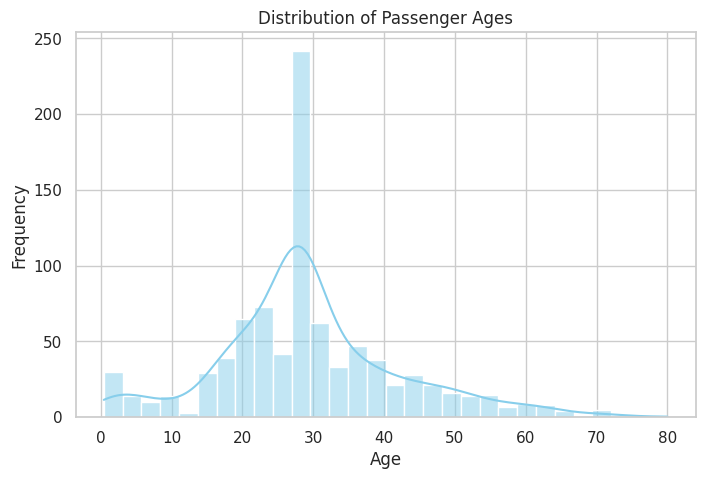

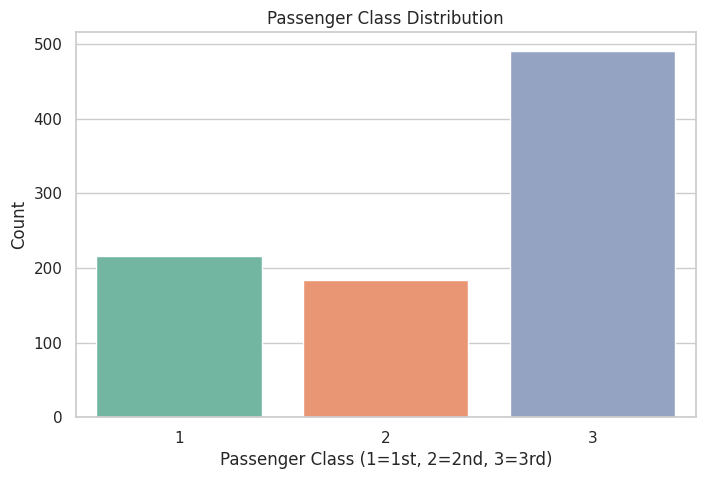

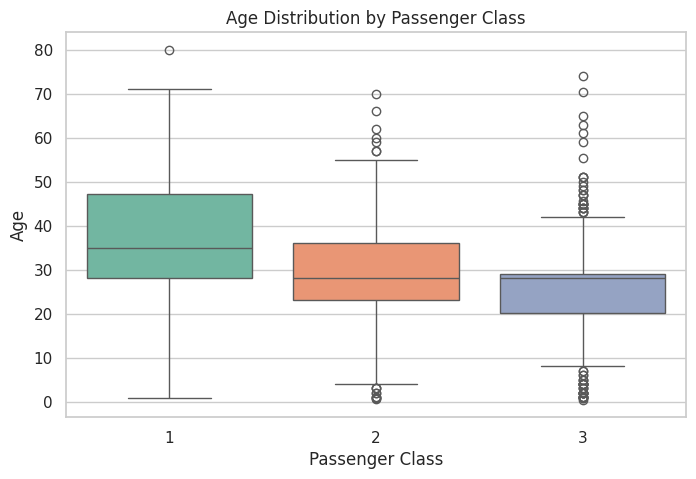

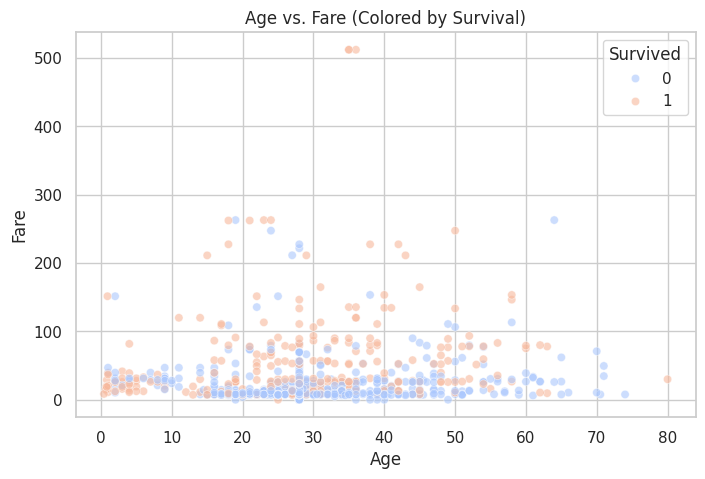

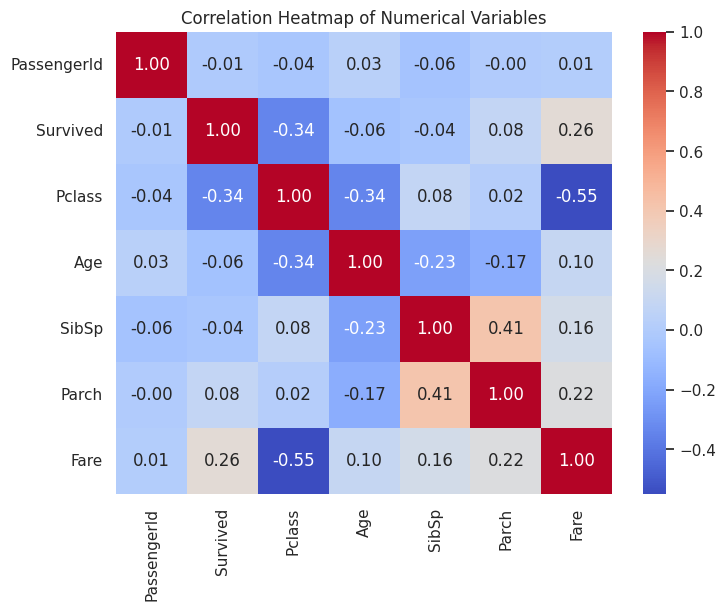

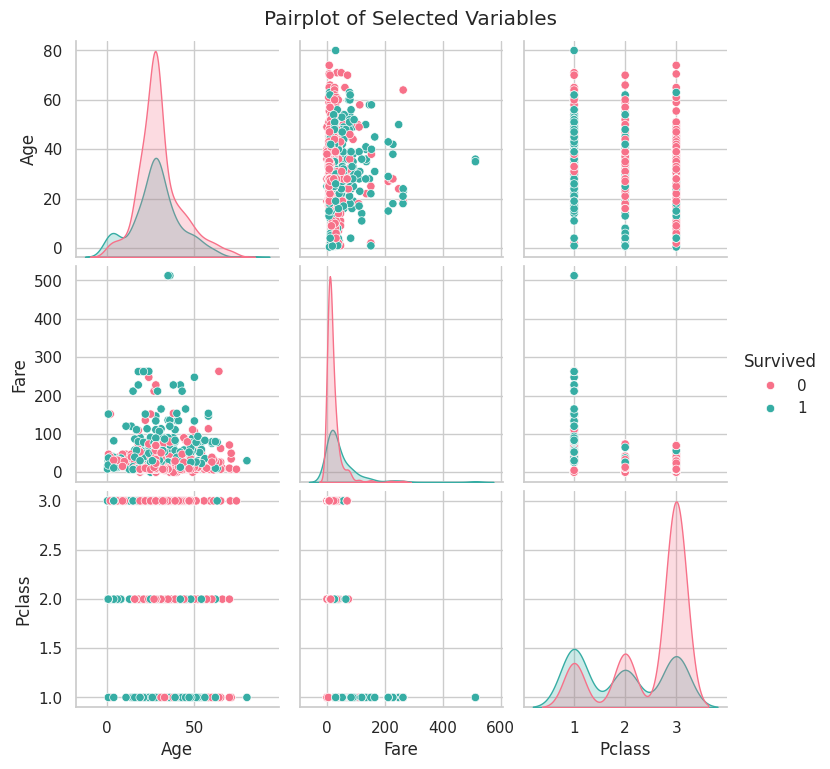

In [31]:
print("Data Visualisation")
# Set the visual style
sns.set_theme(style="whitegrid")

# 1. Histogram of passenger ages
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
# Interpretation: The majority of passengers are between 20 and 30 years old.

# 2. Bar chart showing passenger class distribution
plt.figure(figsize=(8, 5))
# UPDATED: Added hue='Pclass' and legend=False
sns.countplot(data=df, x='Pclass', hue='Pclass', palette='Set2', legend=False)
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class (1=1st, 2=2nd, 3=3rd)')
plt.ylabel('Count')
plt.show()
# Interpretation: Class 3 (Third Class) had the highest number of passengers by a significant margin.

# 3. Boxplot of age by passenger class
plt.figure(figsize=(8, 5))
# UPDATED: Added hue='Pclass' and legend=False
sns.boxplot(data=df, x='Pclass', y='Age', hue='Pclass', palette='Set2', legend=False)
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()
# Interpretation: 1st class passengers tend to be older on average compared to 2nd and 3rd class passengers.

# 4. Scatter plot of Age versus Fare
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived', alpha=0.6, palette='coolwarm')
plt.title('Age vs. Fare (Colored by Survival)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()
# Interpretation: Higher fares slightly correlate with higher survival rates, while age shows a wider, less distinct spread. 

# 5. Correlation Heatmap
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number]) # Filter for numeric columns only
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()
# Interpretation: Highlights linear relationships; for example, Pclass and Fare have a strong negative correlation.

# 6. Pairplot of selected numerical variables
sns.pairplot(df[['Age', 'Fare', 'Pclass', 'Survived']], hue='Survived', palette='husl')
plt.suptitle('Pairplot of Selected Variables', y=1.02)
plt.show()
# Interpretation: Provides a grid view of relationships; higher fares and lower Pclass (1st class) cluster with survivors.

In [32]:
print("Statistical Analysis")
print("--- 1. Descriptive Statistics ---")
display(df.describe())

print("\n--- 2. Frequency Distribution (Categorical Variables) ---")
print("Survived:\n", df['Survived'].value_counts())
print("\nSex:\n", df['Sex'].value_counts())
print("\nEmbarked:\n", df['Embarked'].value_counts())

print("\n--- 3. Correlation Analysis ---")
corr_matrix = numeric_df.corr()
display(corr_matrix)

# 4 & 5. Identify Strongest Correlations programmatically
# Unstack the matrix, remove self-correlations (1.0), and sort
unstacked_corr = corr_matrix.unstack()
unstacked_corr = unstacked_corr[unstacked_corr != 1.0]

strongest_pos = unstacked_corr.idxmax()
strongest_neg = unstacked_corr.idxmin()

print(f"\n4. Strongest Positive Correlation: {strongest_pos} with a value of {unstacked_corr.max():.4f}")
print(f"5. Strongest Negative Correlation: {strongest_neg} with a value of {unstacked_corr.min():.4f}")

print("Important Statistical Findings")
print("1.Survival Rate: A significant majority of the passengers in this dataset did not survive (approx 62% died vs 38% survived based on value counts).\n2.Fare Variability: The Fare variable has an incredibly high standard deviation compared to its mean, indicating massive wealth disparity among passengers.\n3.Class & Wealth Interaction: The strongest negative correlation is between Pclass and Fare. This perfectly aligns with reality: lower class numbers (1st class) correspond to higher ticket prices")


Statistical Analysis
--- 1. Descriptive Statistics ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- 2. Frequency Distribution (Categorical Variables) ---
Survived:
 Survived
0    549
1    342
Name: count, dtype: int64

Sex:
 Sex
male      577
female    314
Name: count, dtype: int64

Embarked:
 Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

--- 3. Correlation Analysis ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000



4. Strongest Positive Correlation: ('SibSp', 'Parch') with a value of 0.4148
5. Strongest Negative Correlation: ('Pclass', 'Fare') with a value of -0.5495
Important Statistical Findings
1.Survival Rate: A significant majority of the passengers in this dataset did not survive (approx 62% died vs 38% survived based on value counts).
2.Fare Variability: The Fare variable has an incredibly high standard deviation compared to its mean, indicating massive wealth disparity among passengers.
3.Class & Wealth Interaction: The strongest negative correlation is between Pclass and Fare. This perfectly aligns with reality: lower class numbers (1st class) correspond to higher ticket prices


In [33]:
print("Machine Learning")
# 1. Select suitable predictor variables
# We map 'Sex' to binary integers so the model can understand it.
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Define Features (X) and Target (y)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features]
y = df['Survived']

# 2. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train a Logistic Regression classifier
# max_iter is increased to ensure the model converges
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Predict the testing data
y_pred = model.predict(X_test)

# 5. Compute Metrics
print("--- Model Accuracy ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred), "\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print("Model Performance Discussion:")
# print("Look at the output of your classification_report. You will likely see an accuracy of around 79-81%. \nThe model is generally better at predicting non-survivors (Class 0) than survivors (Class 1)\n because the dataset is slightly imbalanced (more people died than survived). \nSex and Pclass are likely carrying the heaviest weight in the algorithm's decision-making process.")


Machine Learning
--- Model Accuracy ---
Accuracy: 0.8101

--- Confusion Matrix ---
[[92 13]
 [21 53]] 

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.81      0.88      0.84       105
           1       0.80      0.72      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Model Performance Discussion:
